# Crop Recommendation Using Machine Learning
### Final Version — Rich EDA · Confusion Matrix-Based Model Selection · Human-Readable Output

---
## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)

import pickle

sns.set_theme(style='whitegrid', palette='muted')
print('All libraries loaded.')

All libraries loaded.


---
## 2. Load Data

In [6]:
crop = pd.read_csv('Crop_recommendation.csv')
print('Shape:', crop.shape)
crop.head(10)

Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [8]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [10]:
print('Missing values:\n', crop.isnull().sum())
print('\nDuplicate rows:', crop.duplicated().sum())

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


In [12]:
crop.describe().T.style.background_gradient(cmap='YlOrRd', axis=1)

,count,mean,std,min,25%,50%,75%,max
N,2200.000000,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.000000,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.000000,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.000000,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.000000,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.000000,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.000000,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


---
## 3. Exploratory Data Analysis (EDA)

We run **7 different EDA visualisations** to fully understand the data before modelling.

### 3.1 Class Distribution — How Many Samples Per Crop?

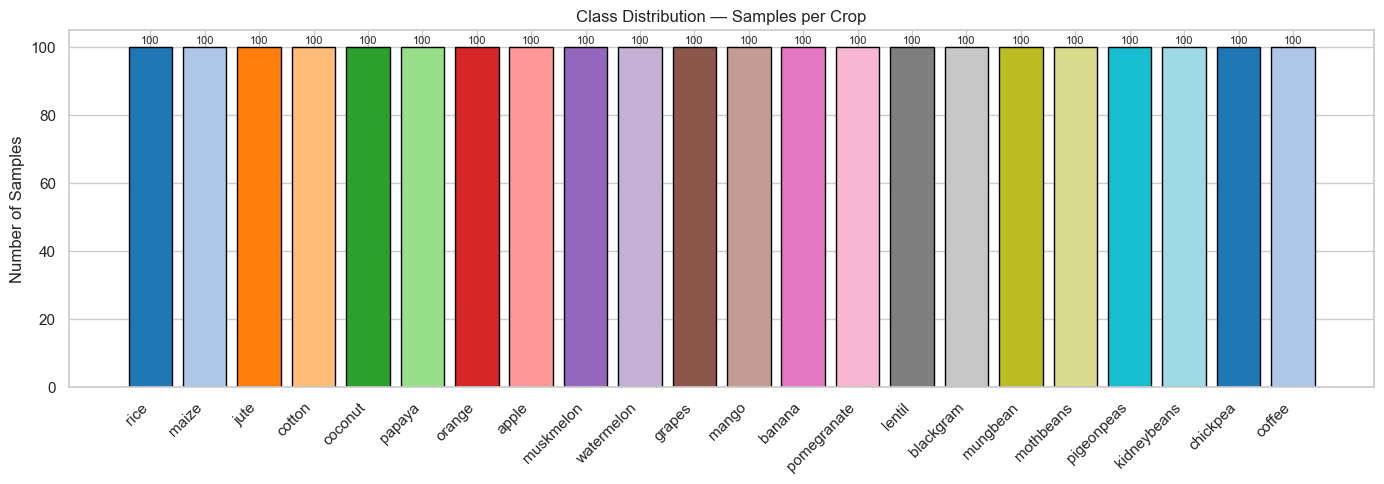

Total crops: 22 | Total samples: 2200
Balanced dataset: 100 to 100 samples per class


In [16]:
label_counts = crop['label'].value_counts()

plt.figure(figsize=(14, 5))
colors = sns.color_palette('tab20', len(label_counts))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Samples')
plt.title('Class Distribution — Samples per Crop')
plt.tight_layout()
plt.show()

print(f'Total crops: {crop["label"].nunique()} | Total samples: {len(crop)}')
print(f'Balanced dataset: {label_counts.min()} to {label_counts.max()} samples per class')

### 3.2 Feature Distributions — Histograms with KDE for All 7 Features

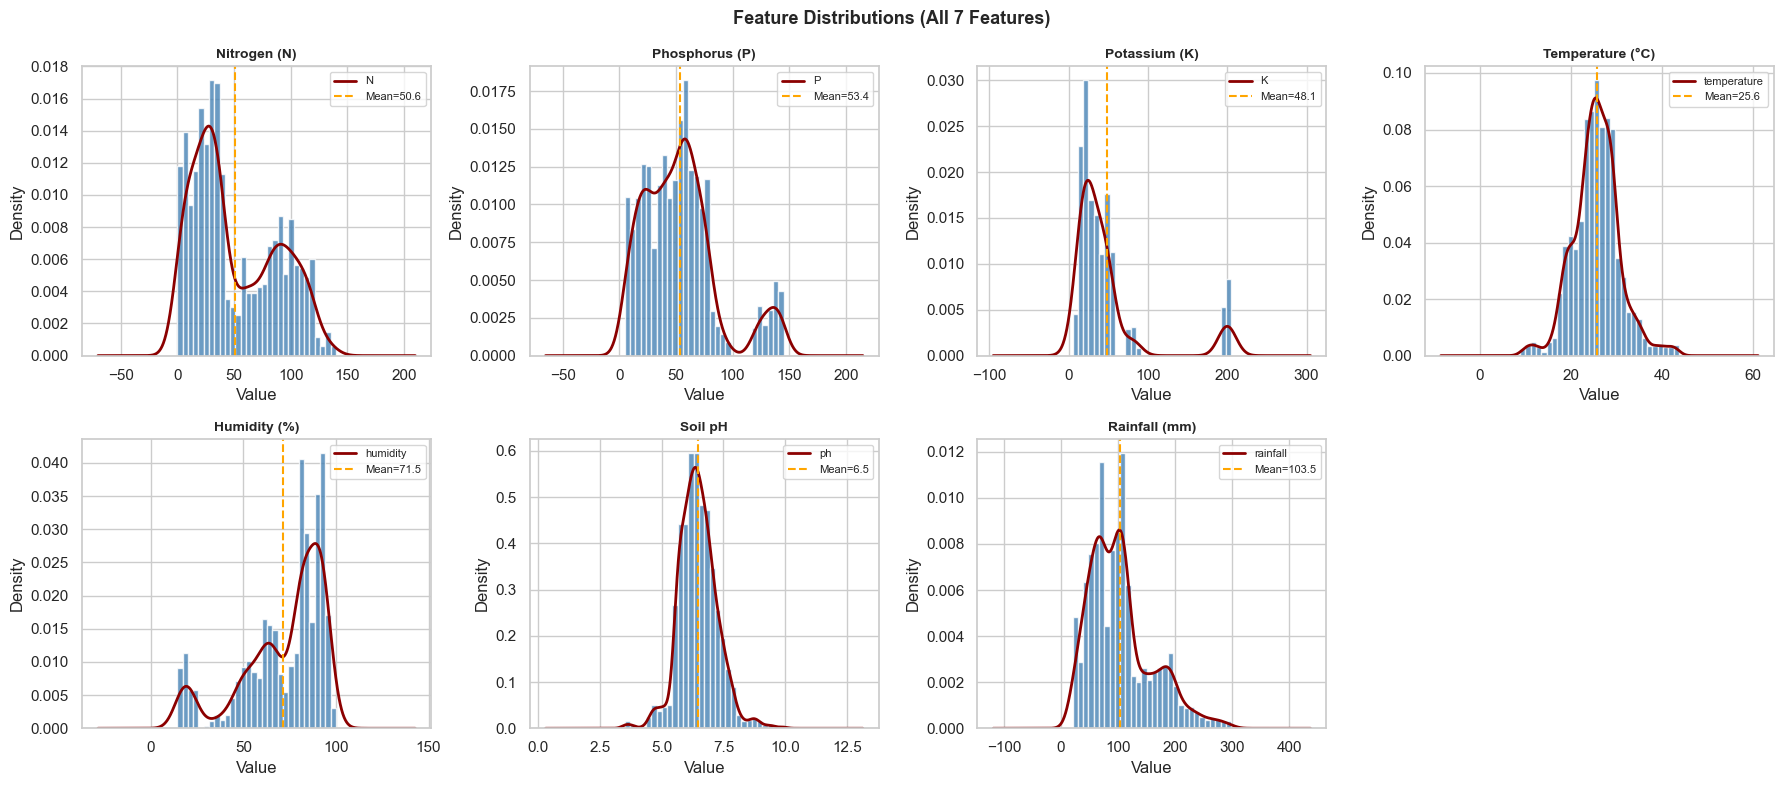

In [19]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
feature_labels = {
    'N': 'Nitrogen (N)', 'P': 'Phosphorus (P)', 'K': 'Potassium (K)',
    'temperature': 'Temperature (°C)', 'humidity': 'Humidity (%)',
    'ph': 'Soil pH', 'rainfall': 'Rainfall (mm)'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(crop[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    crop[feat].plot.kde(ax=axes[i], color='darkred', linewidth=2)
    axes[i].set_title(feature_labels[feat], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    # Annotate with mean and std
    m, s = crop[feat].mean(), crop[feat].std()
    axes[i].axvline(m, color='orange', linestyle='--', linewidth=1.5, label=f'Mean={m:.1f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions (All 7 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Outlier Detection — Box Plots per Feature

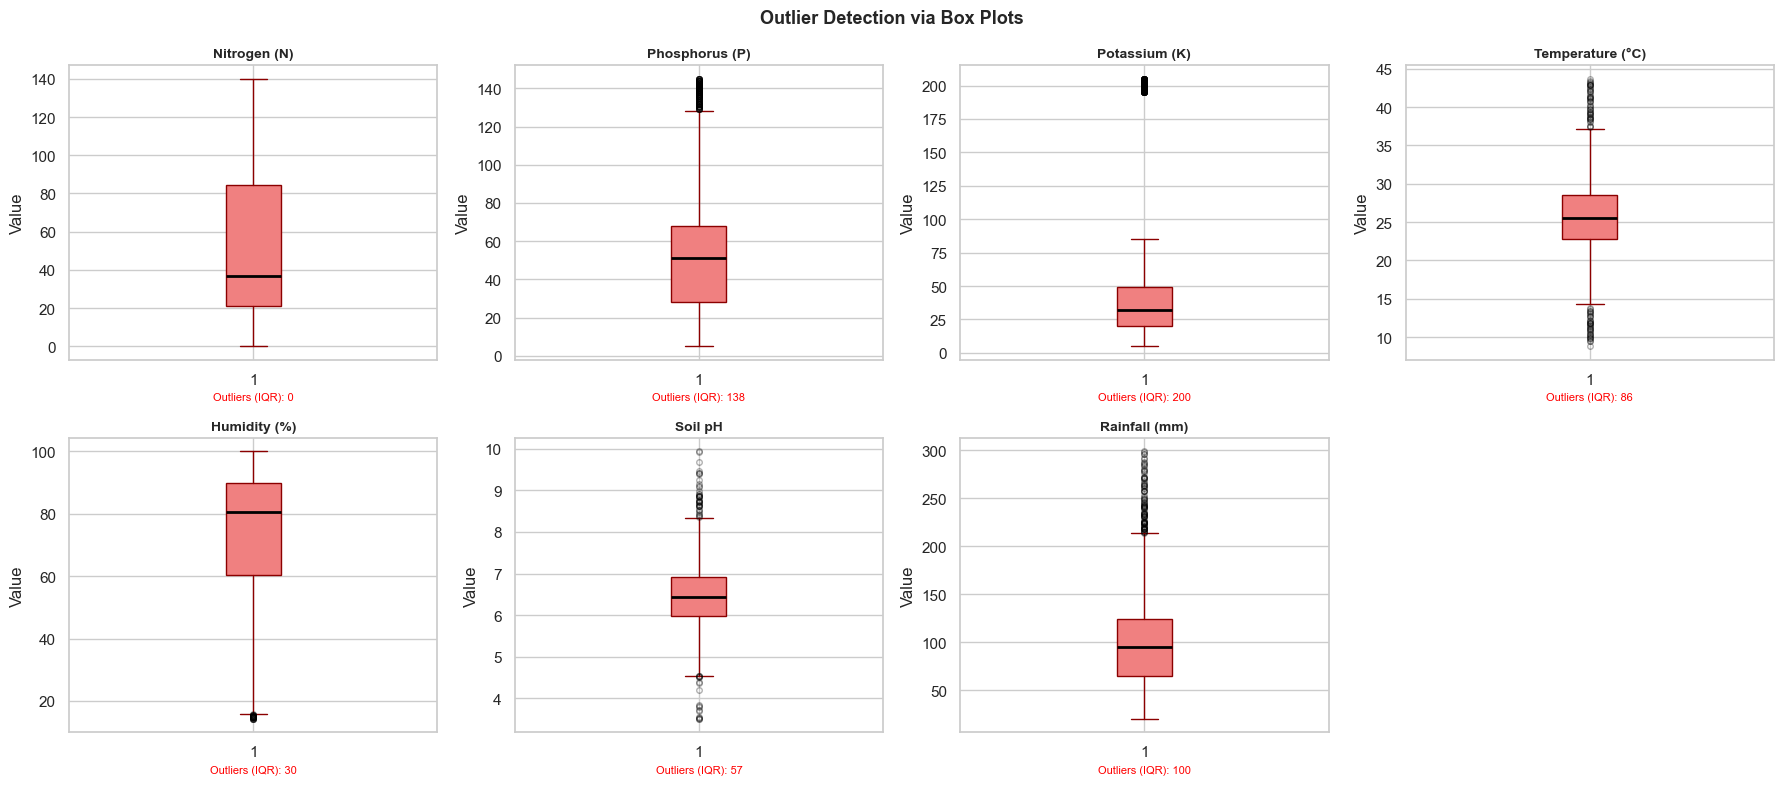

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].boxplot(crop[feat], patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(color='darkred'),
                    capprops=dict(color='darkred'),
                    flierprops=dict(marker='o', color='red', alpha=0.3, markersize=4))
    axes[i].set_title(feature_labels[feat], fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
    # Count outliers using IQR
    Q1, Q3 = crop[feat].quantile(0.25), crop[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((crop[feat] < Q1 - 1.5*IQR) | (crop[feat] > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'Outliers (IQR): {n_outliers}', fontsize=8, color='red')

axes[-1].set_visible(False)
plt.suptitle('Outlier Detection via Box Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Feature Correlation Heatmap

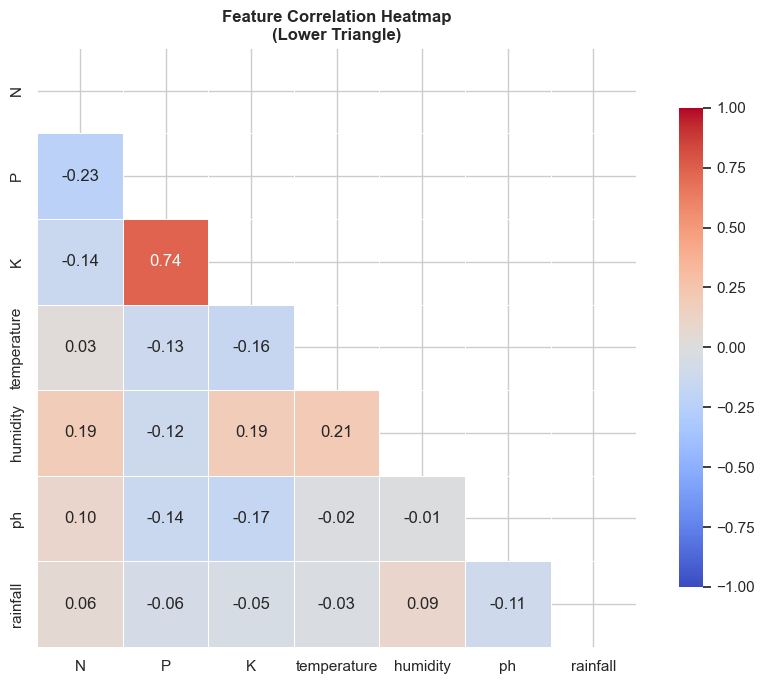

Top 3 Positive Correlations:
P            K           0.736232
temperature  humidity    0.205320
K            humidity    0.190859
dtype: float64

Top 3 Negative Correlations:
K  temperature   -0.160387
   ph            -0.169503
N  P             -0.231460
dtype: float64


In [25]:
corr_matrix = crop[features].corr()

# Mask upper triangle for cleaner view
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap\n(Lower Triangle)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top positive and negative correlations
corr_pairs = corr_matrix.unstack().drop_duplicates().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0]
print('Top 3 Positive Correlations:')
print(corr_pairs.head(3))
print('\nTop 3 Negative Correlations:')
print(corr_pairs.tail(3))

### 3.5 Per-Crop Mean Feature Profile — Heatmap
Shows what **average conditions** each crop prefers.

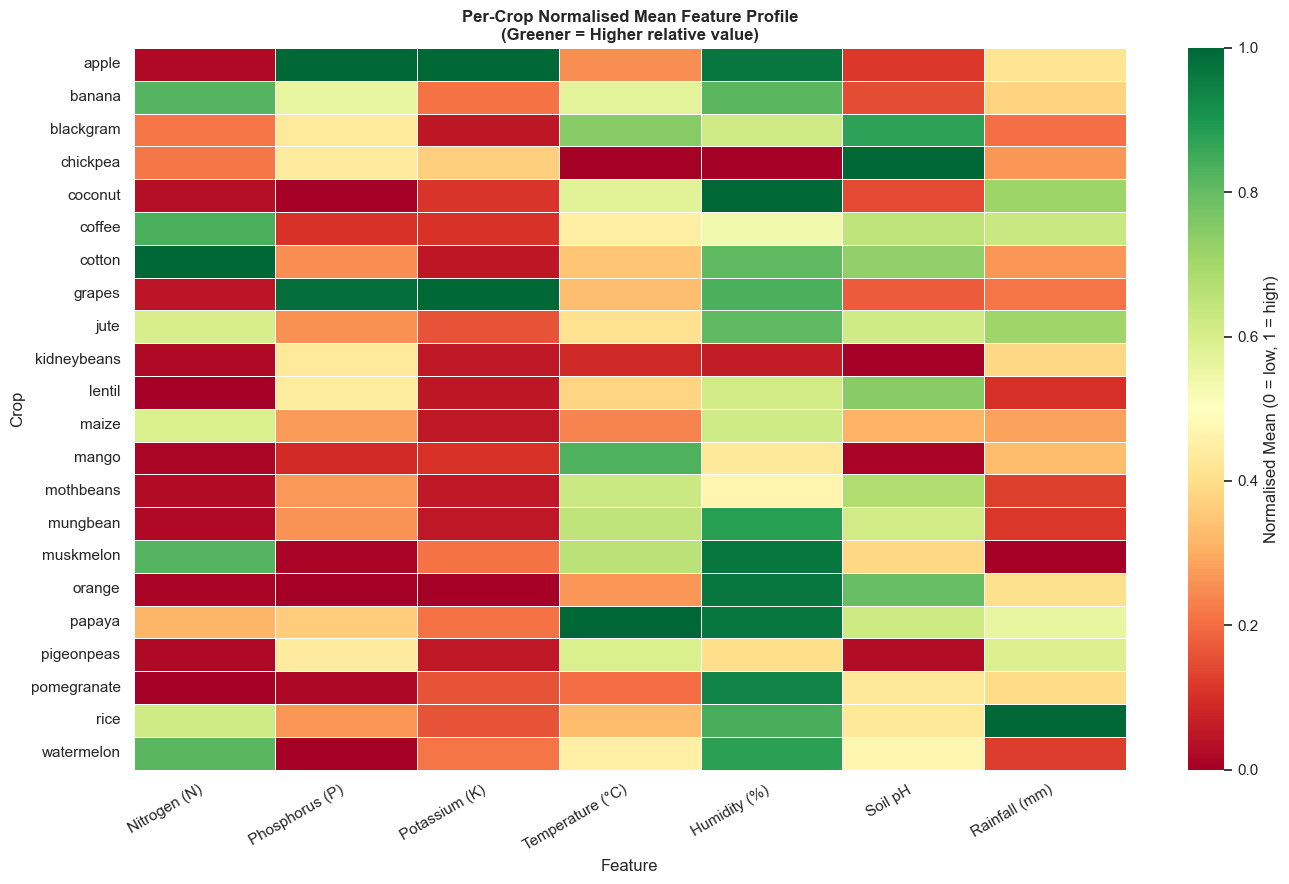

In [28]:
crop_means = crop.groupby('label')[features].mean()

# Normalise each column to 0–1 for fair visual comparison
crop_means_norm = (crop_means - crop_means.min()) / (crop_means.max() - crop_means.min())

plt.figure(figsize=(14, 9))
sns.heatmap(crop_means_norm, annot=False, cmap='RdYlGn', linewidths=0.4,
            xticklabels=[feature_labels[f] for f in features],
            cbar_kws={'label': 'Normalised Mean (0 = low, 1 = high)'})
plt.title('Per-Crop Normalised Mean Feature Profile\n(Greener = Higher relative value)', 
          fontsize=12, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Crop')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 3.6 Violin Plots — Feature Distribution Across Crops
Shows not just the mean but the **spread and shape** of each feature per crop.

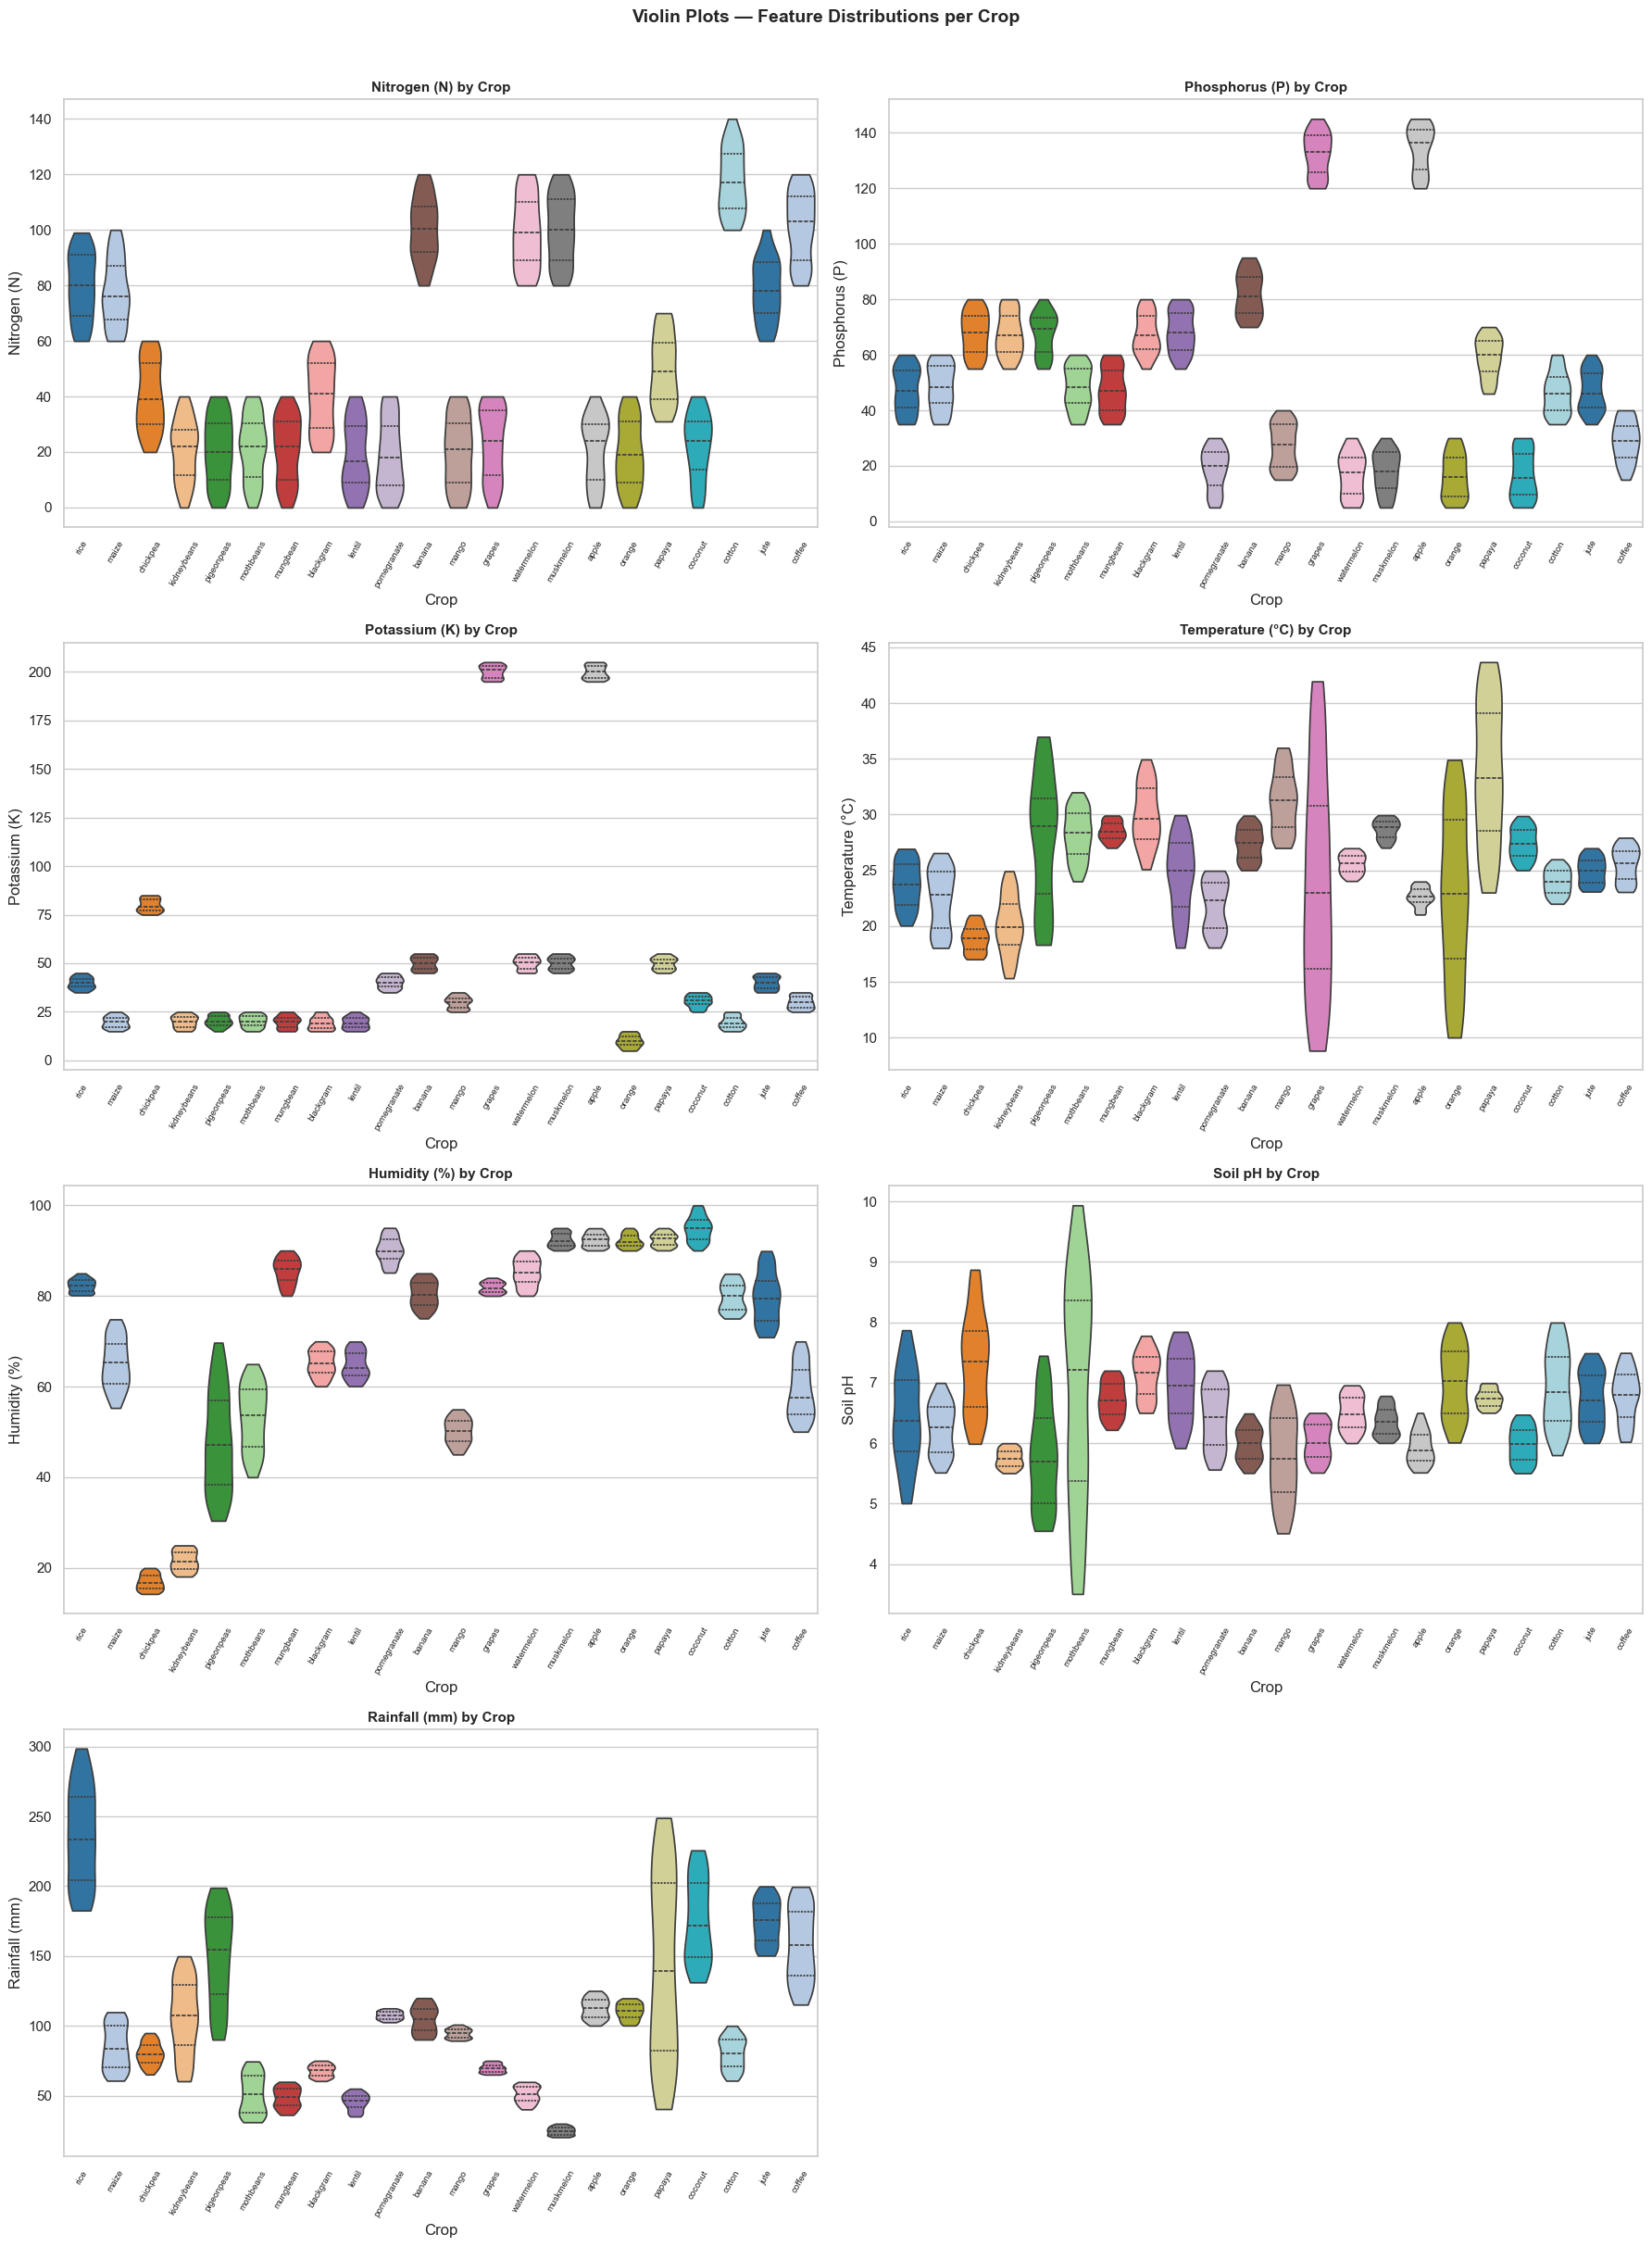

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(
        data=crop, x='label', y=feat,
        ax=axes[i], palette='tab20',
        inner='quartile', cut=0
    )
    axes[i].set_title(f'{feature_labels[feat]} by Crop', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Crop')
    axes[i].set_ylabel(feature_labels[feat])
    axes[i].tick_params(axis='x', rotation=60, labelsize=7)

axes[-1].set_visible(False)
plt.suptitle('Violin Plots — Feature Distributions per Crop', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.7 Pairplot — Key Feature Relationships (N, P, K, pH coloured by Crop)
Reveals clusters, overlaps, and separability between crops.

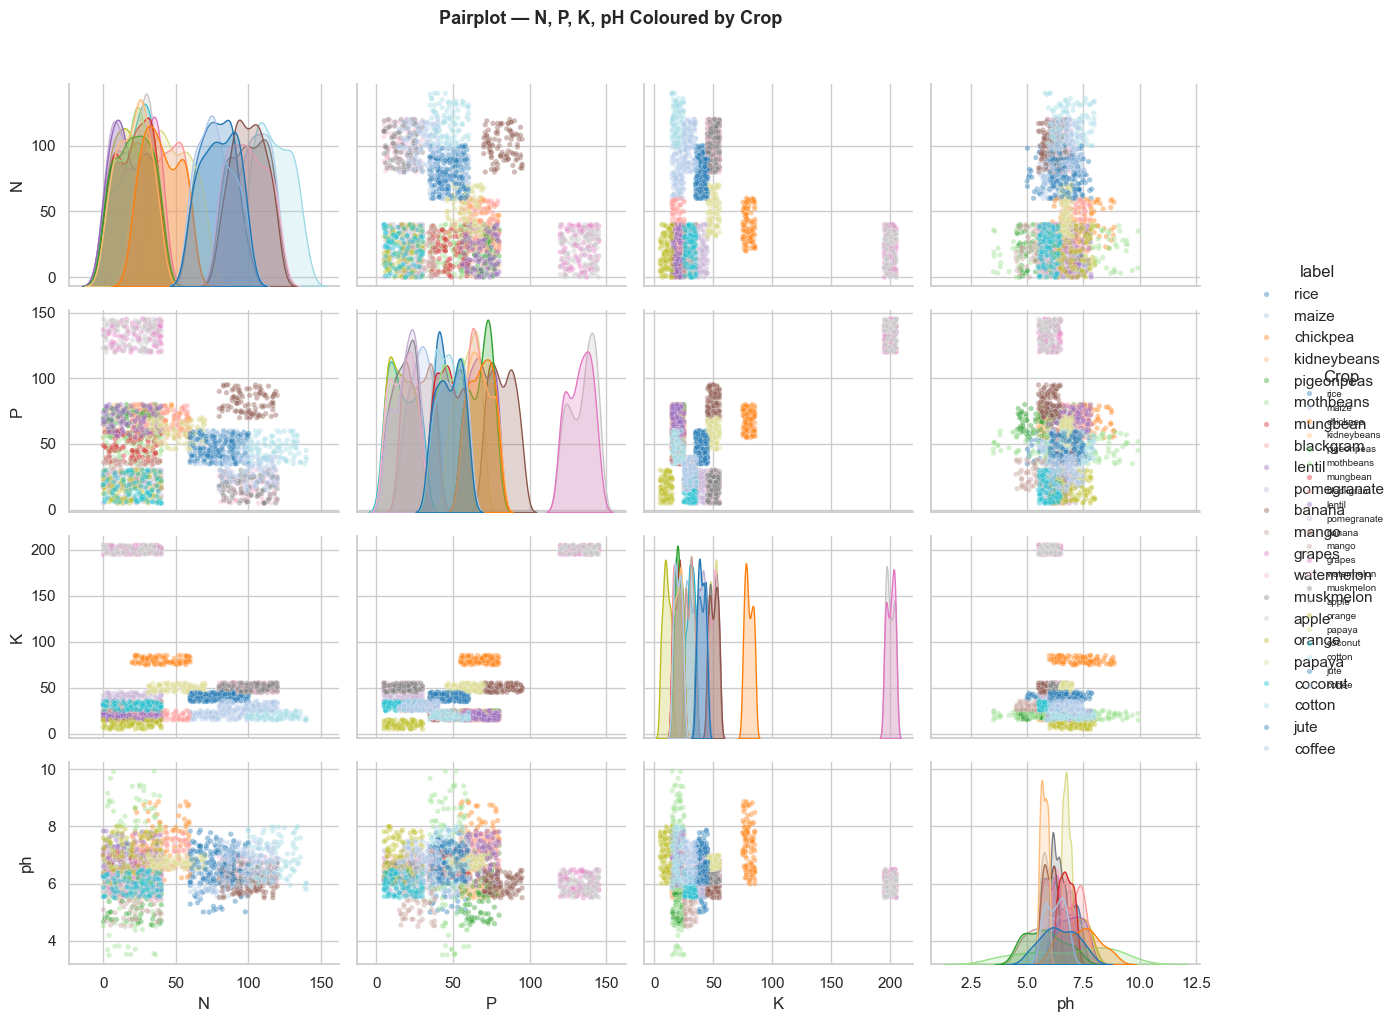

In [34]:
pair_cols = ['N', 'P', 'K', 'ph', 'label']
pairplot_data = crop[pair_cols].copy()

g = sns.pairplot(
    pairplot_data, hue='label',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    palette='tab20'
)
g.fig.suptitle('Pairplot — N, P, K, pH Coloured by Crop', y=1.02, fontsize=13, fontweight='bold')
g.add_legend(title='Crop', bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=7)
plt.tight_layout()
plt.show()

---
## 4. Label Encoding
Encode labels as integers; keep a **reverse dictionary** to decode predictions back to crop names.

In [37]:
crop_dict = {
    'rice': 1, 'maize': 2, 'jute': 3, 'cotton': 4, 'coconut': 5,
    'papaya': 6, 'orange': 7, 'apple': 8, 'muskmelon': 9, 'watermelon': 10,
    'grapes': 11, 'mango': 12, 'banana': 13, 'pomegranate': 14, 'lentil': 15,
    'blackgram': 16, 'mungbean': 17, 'mothbeans': 18, 'pigeonpeas': 19,
    'kidneybeans': 20, 'chickpea': 21, 'coffee': 22
}

# Reverse: number → name (used to decode predictions)
reverse_crop_dict = {v: k for k, v in crop_dict.items()}

crop['label'] = crop['label'].map(crop_dict)
crop_labels = [reverse_crop_dict[i] for i in sorted(reverse_crop_dict.keys())]

print('Encoded. Unique labels:', sorted(crop['label'].unique()))
crop.head()

Encoded. Unique labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


---
## 5. Train-Test Split & Scaling

In [40]:
X = crop.drop('label', axis=1)
y = crop['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1760, 7) | Test: (440, 7)


In [42]:
# Step 1: MinMaxScaler — fit ONLY on train, transform both
mx = MinMaxScaler()
X_train = mx.fit_transform(X_train)
X_test  = mx.transform(X_test)

# Step 2: StandardScaler on top — fit ONLY on train, transform both
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

print('Scaling complete.')

Scaling complete.


---
## 6. Train All Models

In [45]:
models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000),
    'Gaussian Naive Bayes': GaussianNB(),
    'SVM (SVC)':            SVC(),
    'K-Nearest Neighbors':  KNeighborsClassifier(),
    'Decision Tree':        DecisionTreeClassifier(),
    'Extra Trees':          ExtraTreeClassifier(),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Bagging Classifier':   BaggingClassifier(),
    'Gradient Boosting':    GradientBoostingClassifier(),
    'AdaBoost':             AdaBoostClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {'model': model, 'y_pred': y_pred}

print(f'Trained {len(results)} models.')

Trained 10 models.


---
## 7. Confusion Matrix-Based Model Evaluation

**Accuracy alone can be misleading.** A model may have high accuracy but consistently fail on specific crops. 
We extract 5 metrics from each model's confusion matrix:

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| **Accuracy** | Overall correct predictions | General performance baseline |
| **Weighted Precision** | When model predicts crop X, how often is it right? | Penalises false alarms |
| **Weighted Recall** | Of all actual crop X samples, how many did it find? | Penalises missed detections |
| **Weighted F1** | Harmonic mean of precision & recall | Balances both, best single metric |
| **Cohen's Kappa** | Agreement beyond chance | Robust to class imbalance |
| **MCC** | Matthews Correlation Coefficient | Best for multi-class, uses entire confusion matrix |

The **composite score** = `0.20×Accuracy + 0.20×F1 + 0.20×Precision + 0.15×Recall + 0.15×Kappa + 0.10×MCC`

### 7.1 Confusion Matrices for All Models

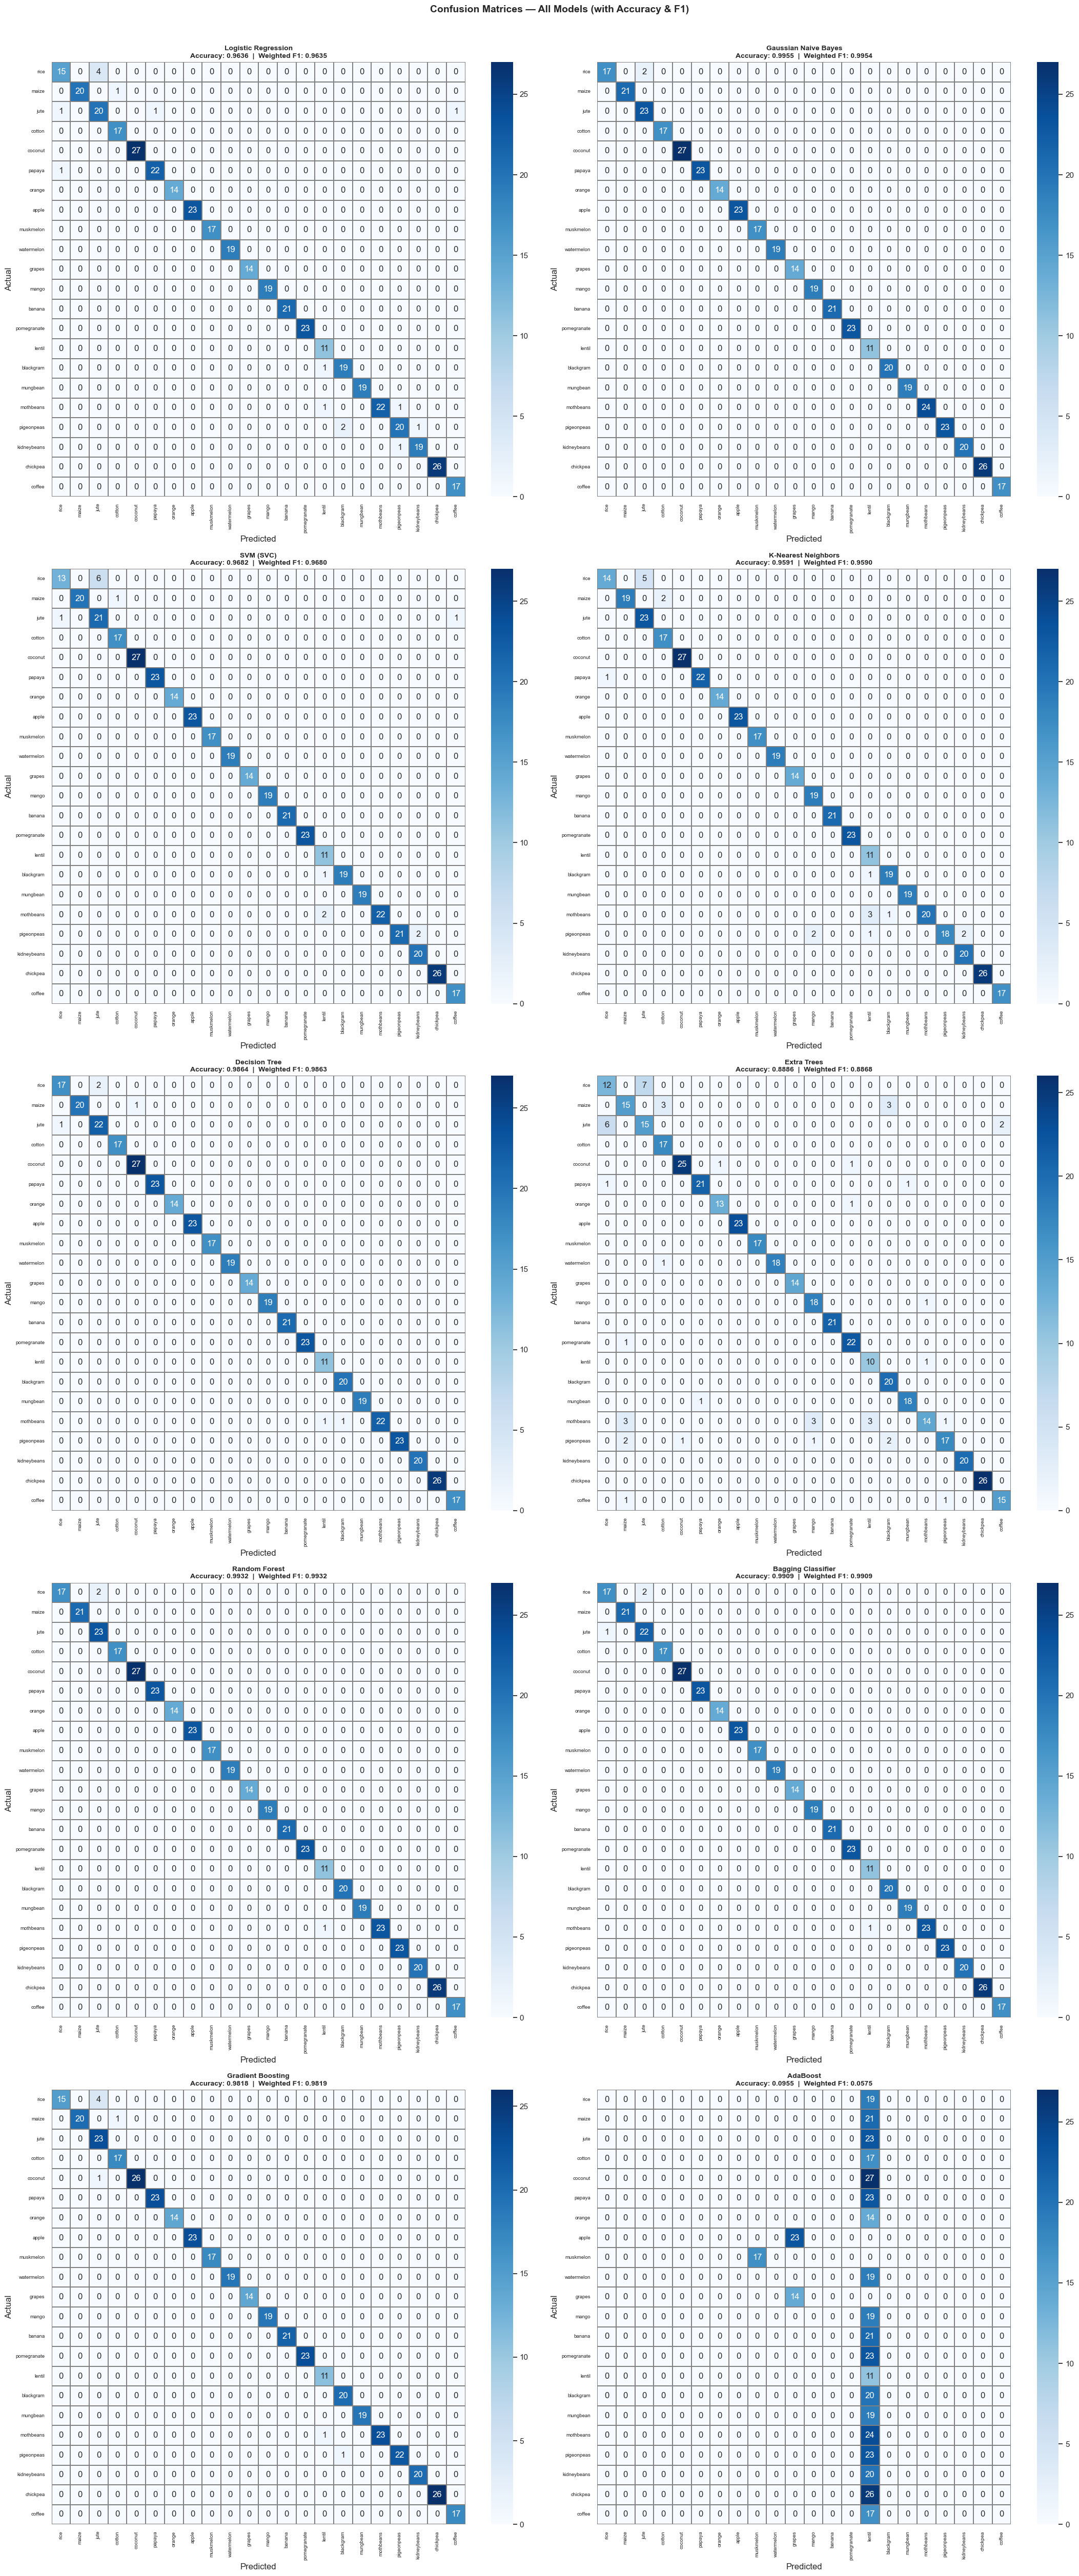

In [49]:
n_models = len(results)
cols = 2
rows = (n_models + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm_mat = confusion_matrix(y_test, res['y_pred'])
    acc = accuracy_score(y_test, res['y_pred'])
    f1  = f1_score(y_test, res['y_pred'], average='weighted')

    sns.heatmap(
        cm_mat, annot=True, fmt='d', cmap='Blues',
        xticklabels=crop_labels, yticklabels=crop_labels,
        ax=axes[idx], linewidths=0.3, linecolor='gray'
    )
    axes[idx].set_title(
        f'{name}\nAccuracy: {acc:.4f}  |  Weighted F1: {f1:.4f}',
        fontsize=10, fontweight='bold'
    )
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].tick_params(axis='x', rotation=90, labelsize=7)
    axes[idx].tick_params(axis='y', rotation=0,  labelsize=7)

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (with Accuracy & F1)',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

### 7.2 Build the Full Metrics Table from the Confusion Matrix

In [52]:
metrics_rows = []

for name, res in results.items():
    yp = res['y_pred']

    acc       = accuracy_score(y_test, yp)
    precision = precision_score(y_test, yp, average='weighted', zero_division=0)
    recall    = recall_score(y_test, yp, average='weighted', zero_division=0)
    f1        = f1_score(y_test, yp, average='weighted', zero_division=0)
    kappa     = cohen_kappa_score(y_test, yp)
    mcc       = matthews_corrcoef(y_test, yp)

    # Composite score (weighted combination)
    composite = (0.20 * acc + 0.20 * f1 + 0.20 * precision
                 + 0.15 * recall + 0.15 * kappa + 0.10 * mcc)

    metrics_rows.append({
        'Model':          name,
        'Accuracy':       round(acc, 4),
        'Precision (W)':  round(precision, 4),
        'Recall (W)':     round(recall, 4),
        'F1 (W)':         round(f1, 4),
        "Cohen's Kappa":  round(kappa, 4),
        'MCC':            round(mcc, 4),
        'Composite Score':round(composite, 4)
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('Composite Score', ascending=False)
metrics_df = metrics_df.reset_index(drop=True)
metrics_df.index += 1  # rank starts at 1

print('Model Evaluation Summary (sorted by Composite Score)')
metrics_df.style \
    .background_gradient(subset=['Accuracy','Precision (W)','Recall (W)','F1 (W)',
                                  "Cohen's Kappa",'MCC','Composite Score'],
                         cmap='RdYlGn') \
    .highlight_max(subset=['Composite Score'], color='#00cc66') \
    .format({c: '{:.4f}' for c in metrics_df.columns if c != 'Model'})

Model Evaluation Summary (sorted by Composite Score)


,Model,Accuracy,Precision (W),Recall (W),F1 (W),Cohen's Kappa,MCC,Composite Score
1,Gaussian Naive Bayes,0.9955,0.9958,0.9955,0.9954,0.9952,0.9953,0.9955
2,Random Forest,0.9932,0.9937,0.9932,0.9932,0.9928,0.9929,0.9932
3,Bagging Classifier,0.9909,0.9912,0.9909,0.9909,0.9905,0.9905,0.9908
4,Decision Tree,0.9864,0.9868,0.9864,0.9863,0.9857,0.9857,0.9863
5,Gradient Boosting,0.9818,0.9843,0.9818,0.9819,0.9809,0.9810,0.9821
6,SVM (SVC),0.9682,0.9715,0.9682,0.9680,0.9666,0.9668,0.9684
7,Logistic Regression,0.9636,0.9644,0.9636,0.9635,0.9618,0.9619,0.9633
8,K-Nearest Neighbors,0.9591,0.9654,0.9591,0.9590,0.9571,0.9574,0.9599
9,Extra Trees,0.8886,0.8917,0.8886,0.8868,0.8832,0.8835,0.8876
10,AdaBoost,0.0955,0.0514,0.0955,0.0575,0.0712,0.1509,0.0810


### 7.3 Multi-Metric Bar Chart — Side by Side Comparison

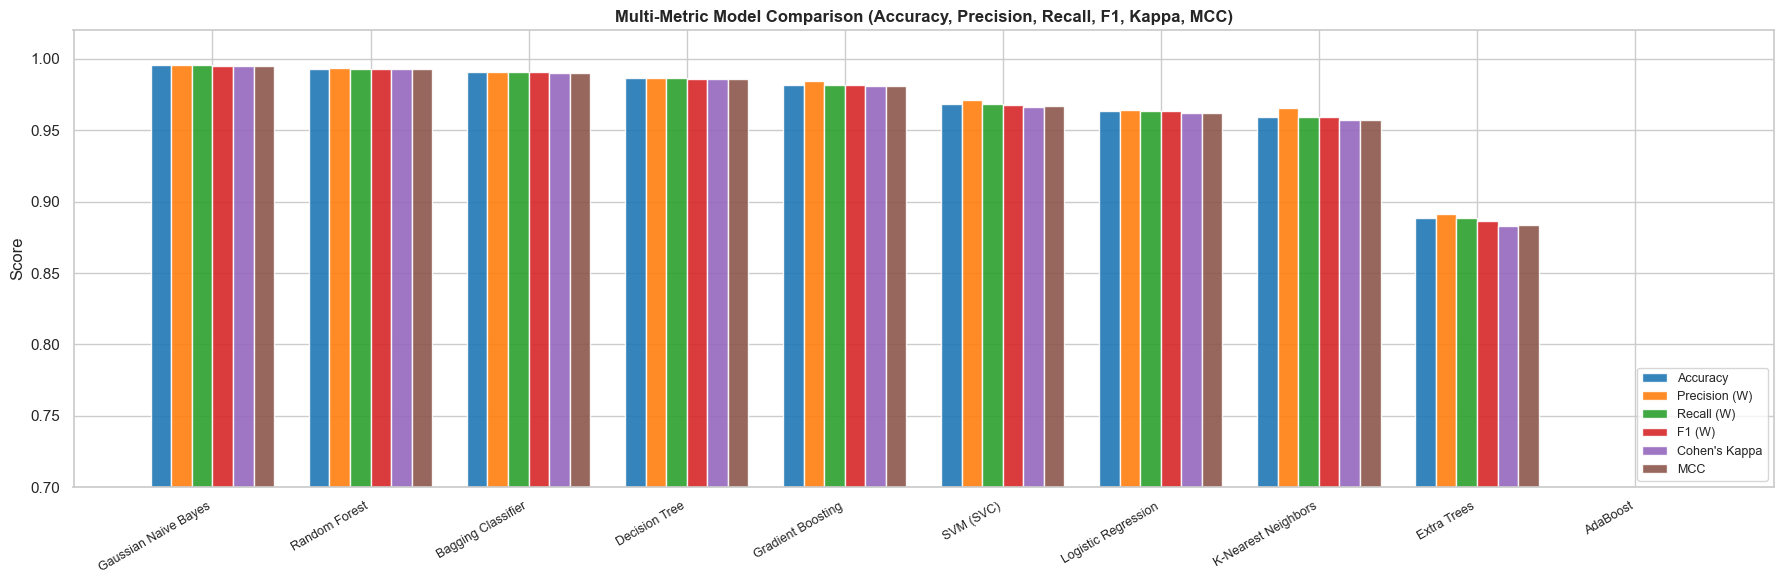

In [55]:
plot_metrics = ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1 (W)', "Cohen's Kappa", 'MCC']
plot_df = metrics_df.set_index('Model')[plot_metrics]

x = np.arange(len(plot_df))
n_metrics = len(plot_metrics)
width = 0.13
colors = sns.color_palette('tab10', n_metrics)

fig, ax = plt.subplots(figsize=(18, 6))
for i, (metric, color) in enumerate(zip(plot_metrics, colors)):
    offset = (i - n_metrics / 2) * width + width / 2
    ax.bar(x + offset, plot_df[metric], width, label=metric, color=color, edgecolor='white', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.02)
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Multi-Metric Model Comparison (Accuracy, Precision, Recall, F1, Kappa, MCC)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Radar Chart — All Metrics per Model

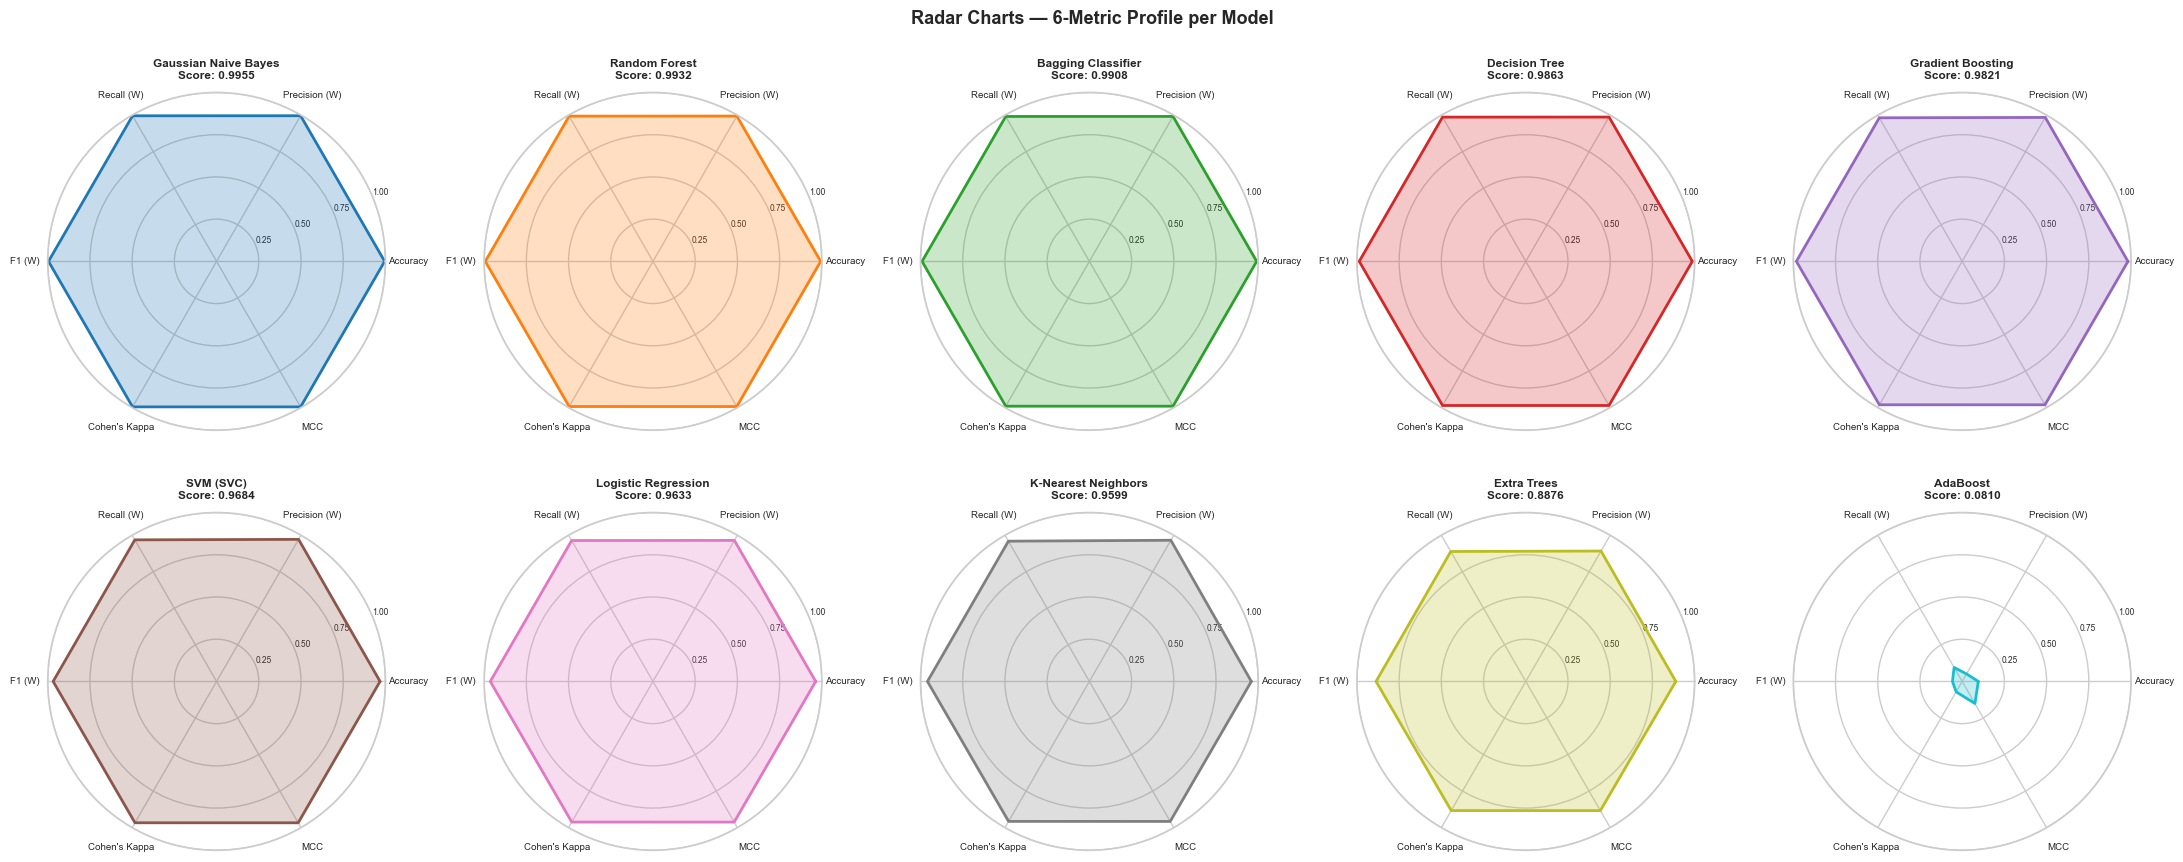

In [58]:
radar_metrics = ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1 (W)', "Cohen's Kappa", 'MCC']
N_axes = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N_axes, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(2, 5, figsize=(22, 9), subplot_kw=dict(polar=True))
axes = axes.flatten()
palette = sns.color_palette('tab10', len(metrics_df))

for idx, (_, row) in enumerate(metrics_df.iterrows()):
    values = [row[m] for m in radar_metrics]
    values += values[:1]
    ax = axes[idx]
    ax.plot(angles, values, color=palette[idx], linewidth=2)
    ax.fill(angles, values, color=palette[idx], alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=6)
    score = row['Composite Score']
    ax.set_title(f"{row['Model']}\nScore: {score:.4f}", fontsize=8.5, fontweight='bold', pad=10)

plt.suptitle('Radar Charts — 6-Metric Profile per Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Select the Best Model

In [61]:
best_row   = metrics_df.iloc[0]   # already sorted descending by composite score
best_name  = best_row['Model']
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']

print('=' * 60)
print(f'  🏆  Best Model (by Composite Score): {best_name}')
print('=' * 60)
for m in ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1 (W)', "Cohen's Kappa", 'MCC', 'Composite Score']:
    print(f'  {m:<20}: {best_row[m]:.4f}')
print()
print('Full Classification Report (per crop):')
print(classification_report(y_test, best_pred, target_names=crop_labels))

  🏆  Best Model (by Composite Score): Gaussian Naive Bayes
  Accuracy            : 0.9955
  Precision (W)       : 0.9958
  Recall (W)          : 0.9955
  F1 (W)              : 0.9954
  Cohen's Kappa       : 0.9952
  MCC                 : 0.9953
  Composite Score     : 0.9955

Full Classification Report (per crop):
              precision    recall  f1-score   support

        rice       1.00      0.89      0.94        19
       maize       1.00      1.00      1.00        21
        jute       0.92      1.00      0.96        23
      cotton       1.00      1.00      1.00        17
     coconut       1.00      1.00      1.00        27
      papaya       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        14
       apple       1.00      1.00      1.00        23
   muskmelon       1.00      1.00      1.00        17
  watermelon       1.00      1.00      1.00        19
      grapes       1.00      1.00      1.00        14
       mango       1.00      1.00  

### Best Model — Detailed Confusion Matrix

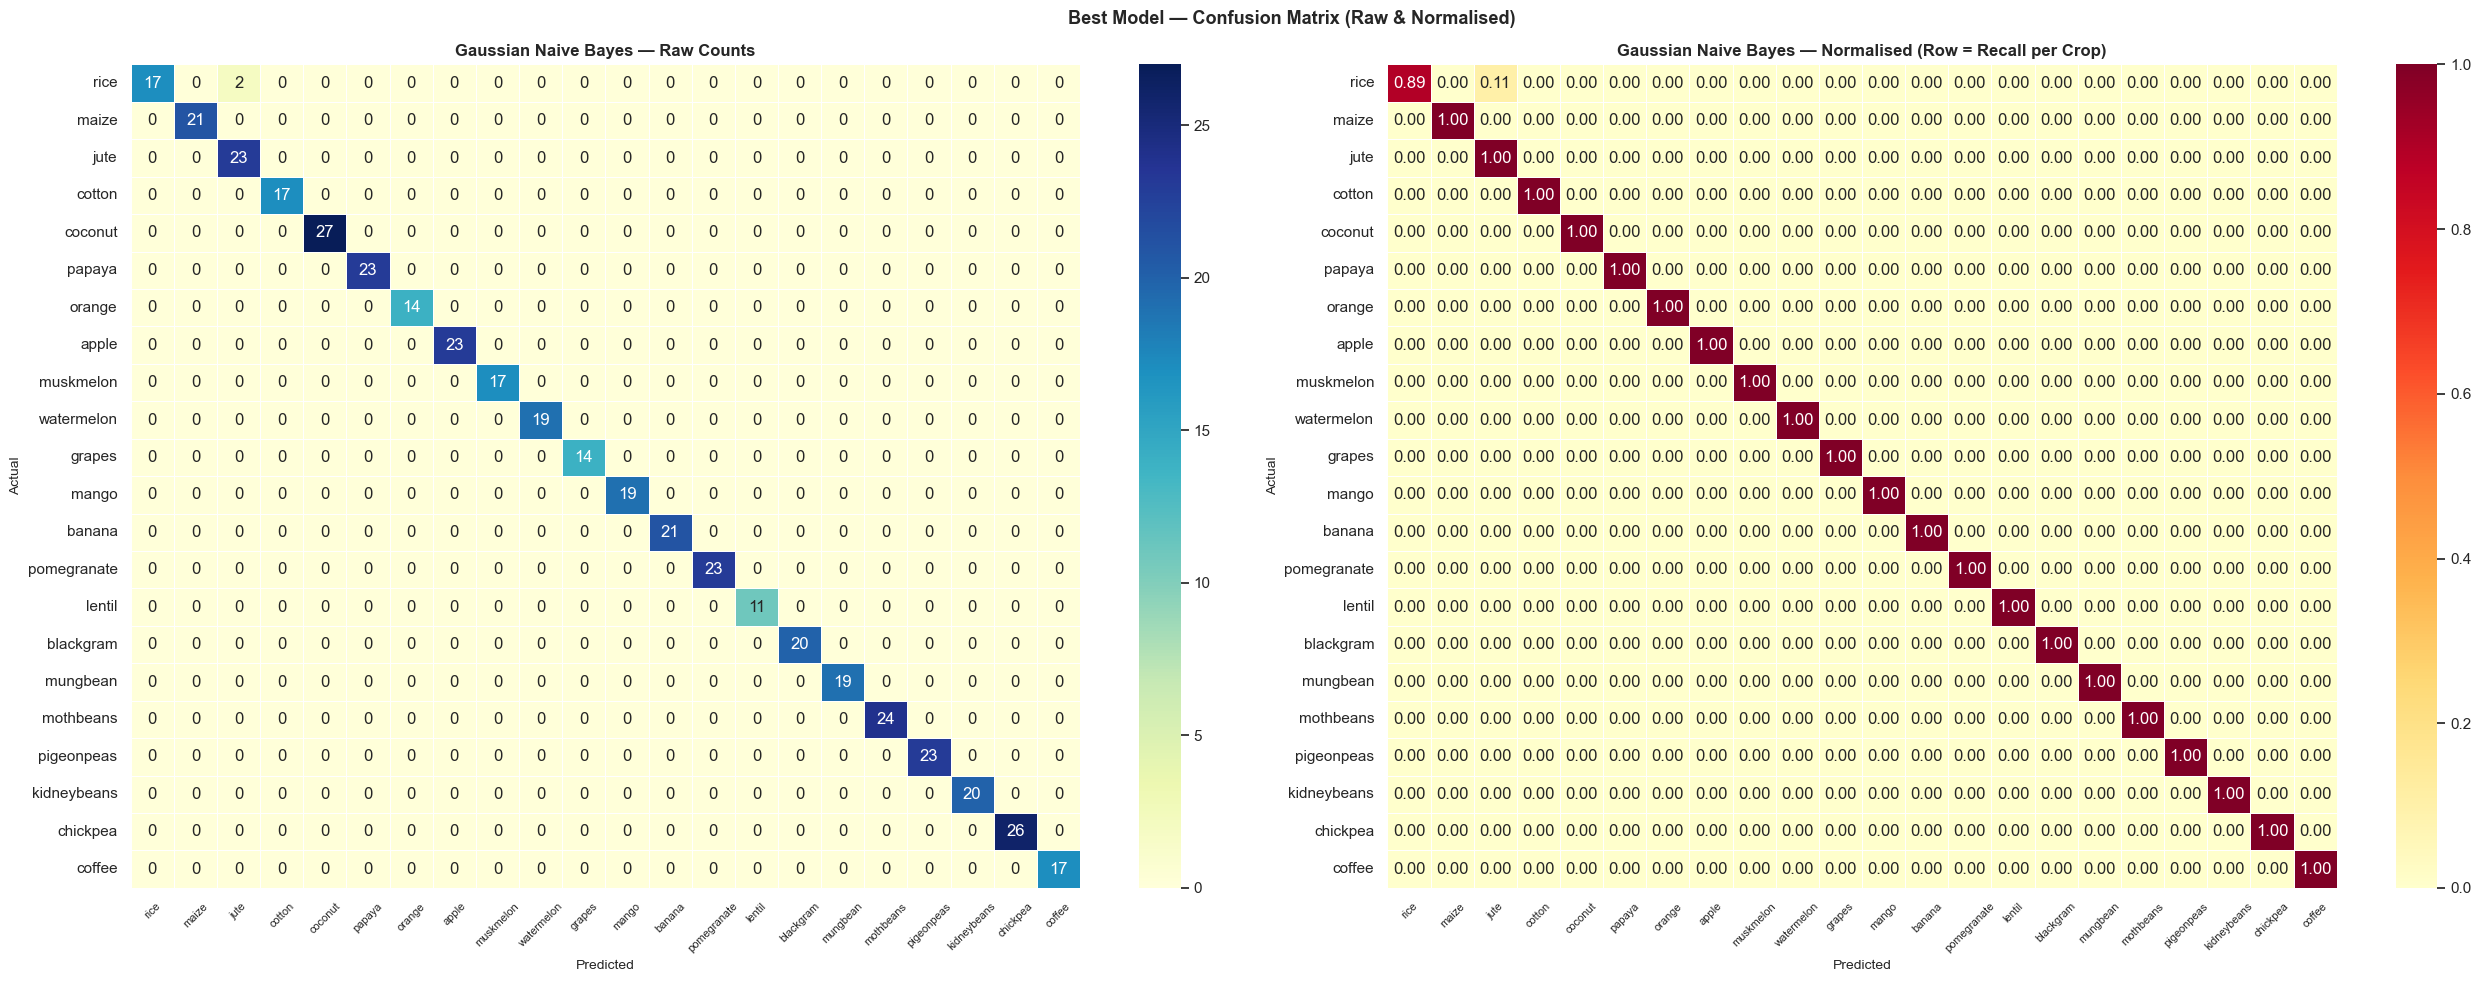

In [64]:
cm_best = confusion_matrix(y_test, best_pred)

# Normalised version (row-wise recall per class)
cm_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(26, 10))

# Raw counts
sns.heatmap(cm_best, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=crop_labels, yticklabels=crop_labels,
            ax=axes[0], linewidths=0.4)
axes[0].set_title(f'{best_name} — Raw Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('Actual', fontsize=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

# Normalised (per-class recall)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=crop_labels, yticklabels=crop_labels,
            ax=axes[1], linewidths=0.4, vmin=0, vmax=1)
axes[1].set_title(f'{best_name} — Normalised (Row = Recall per Crop)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('Actual', fontsize=10)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Best Model — Confusion Matrix (Raw & Normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Crop Recommendation Function
Returns **crop name** (e.g. `'rice'`, `'mango'`) — not a number.

> ⚠️ **Bug fix**: Original notebook used `fit_transform` inside `recommendation()` which re-trained scalers on a single sample — producing incorrect predictions. Corrected to `transform` only.

In [67]:
def recommendation(N, P, K, temperature, humidity, ph, rainfall):
    """
    Recommend the best crop for given soil/climate conditions.

    Parameters
    ----------
    N, P, K          : Nitrogen, Phosphorus, Potassium in soil
    temperature      : Temperature in °C
    humidity         : Relative humidity in %
    ph               : Soil pH value
    rainfall         : Annual rainfall in mm

    Returns
    -------
    str  — crop name, e.g. 'rice', 'mango', 'apple'
    """
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])

    # Use transform only (scalers already fitted on training data)
    mx_features = mx.transform(features)
    sc_features = sc.transform(mx_features)

    pred_num  = best_model.predict(sc_features)[0]
    crop_name = reverse_crop_dict.get(pred_num, 'Unknown')
    return crop_name

In [69]:
# Example prediction
N=90; P=42; K=43
temperature=20.879744; humidity=82.002744; ph=6.502985; rainfall=202.935536

result = recommendation(N, P, K, temperature, humidity, ph, rainfall)
print(f'🌾 Recommended Crop: {result.upper()}')

🌾 Recommended Crop: RICE


In [71]:
# Test multiple samples — all output should be human-readable crop names
test_cases = [
    ('rice sample 1',  90,  42,  43, 20.88, 82.00, 6.50, 202.94),
    ('rice sample 2',  85,  58,  41, 21.77, 80.32, 7.04, 226.66),
    ('maize sample',   60,  55,  44, 28.00, 54.90, 7.84,  94.50),
    ('mango sample',   20,  30,  30, 31.00, 50.00, 6.00, 100.00),
    ('coffee sample',  18,  21,  30, 26.00, 60.00, 6.80, 200.00),
]

print(f"{'Label':<18} {'N':>4} {'P':>4} {'K':>4} {'Temp':>7} {'Hum':>7} {'pH':>5} {'Rain':>8}   →   Predicted Crop")
print('-' * 90)
for row in test_cases:
    label, *vals = row
    pred = recommendation(*vals)
    print(f"{label:<18} {vals[0]:>4} {vals[1]:>4} {vals[2]:>4} {vals[3]:>7.2f} {vals[4]:>7.2f} {vals[5]:>5.2f} {vals[6]:>8.2f}   →   {pred}")

Label                 N    P    K    Temp     Hum    pH     Rain   →   Predicted Crop
------------------------------------------------------------------------------------------
rice sample 1        90   42   43   20.88   82.00  6.50   202.94   →   rice
rice sample 2        85   58   41   21.77   80.32  7.04   226.66   →   rice
maize sample         60   55   44   28.00   54.90  7.84    94.50   →   mango
mango sample         20   30   30   31.00   50.00  6.00   100.00   →   mango
coffee sample        18   21   30   26.00   60.00  6.80   200.00   →   coffee


---
## 10. Save Model & Scalers

In [74]:
pickle.dump(best_model,        open('model.pkl',             'wb'))
pickle.dump(mx,                open('minmaxscaler.pkl',      'wb'))
pickle.dump(sc,                open('standscaler.pkl',       'wb'))
pickle.dump(reverse_crop_dict, open('reverse_crop_dict.pkl', 'wb'))
metrics_df.to_csv('model_evaluation.csv', index=False)

print(f'✅ Saved best model   : {best_name}  →  model.pkl')
print(f'✅ Saved scalers      : minmaxscaler.pkl, standscaler.pkl')
print(f'✅ Saved label decoder: reverse_crop_dict.pkl')
print(f'✅ Saved eval table   : model_evaluation.csv')

✅ Saved best model   : Gaussian Naive Bayes  →  model.pkl
✅ Saved scalers      : minmaxscaler.pkl, standscaler.pkl
✅ Saved label decoder: reverse_crop_dict.pkl
✅ Saved eval table   : model_evaluation.csv
